In [2]:
import pandas as pd
from rdkit import Chem
import numpy as np
from rdkit.Chem import rdFMCS



In [5]:
def is_mol(mol):
    """Check if input is an RDKit molecule object"""
    return isinstance(mol, Chem.rdchem.Mol)

def smiles_to_mol(smiles):
    """Convert SMILES to RDKit molecule"""
    return Chem.MolFromSmiles(smiles)

def __remove_bonds_in_smarts(mol, smarts):
    """Remove bonds in a molecule based on a SMARTS pattern."""
    removed_bond_number = 0
    pattern = Chem.MolFromSmarts(smarts)
    Chem.GetSymmSSSR(pattern)
    Chem.GetSymmSSSR(mol)
    sub_atom = mol.GetSubstructMatch(pattern)
    for i in sub_atom:
        all_bonds = mol.GetAtomWithIdx(i).GetBonds()
        for bond in all_bonds:
            atom_1, atom_2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            mol.RemoveBond(atom_1, atom_2)
            if atom_1 in sub_atom and atom_2 in sub_atom:
                removed_bond_number += 1
    return mol, removed_bond_number

def get_bond_similarity(mol1, mol2):
    """Calculate bond similarity between two molecules"""
    if not is_mol(mol1):
        mol1 = smiles_to_mol(mol1)
    if not is_mol(mol2):
        mol2 = smiles_to_mol(mol2)
    
    if mol1 is None or mol2 is None:
        return {
            "bond_similarity": 0,
            "mol1_bond_number": 0,
            "mol2_bond_number": 0,
            "common_bond_number": 0,
            "bond_difference": 0,
            "minimal_diff": 0
        }
    
    mol1 = Chem.rdchem.RWMol(mol1)
    mol2 = Chem.rdchem.RWMol(mol2)
    bond_number_common = 0
    bond_number_mol1 = len(mol1.GetBonds())
    bond_number_mol2 = len(mol2.GetBonds())
    
    while True:
        res = rdFMCS.FindMCS(
            [mol1, mol2],
            timeout=20,
            threshold=1
        )
        if res.numBonds == 0:
            break
        
        common_s = res.smartsString
        mol1, _ = __remove_bonds_in_smarts(mol1, common_s)
        mol2, _ = __remove_bonds_in_smarts(mol2, common_s)
        bond_number_common += res.numBonds
        minimal_diff = np.min([bond_number_mol1-bond_number_common, bond_number_mol2-bond_number_common])
    
    return {
        "mol1_bond_number": bond_number_mol1,
        "mol2_bond_number": bond_number_mol2,
        "common_bond_number": bond_number_common,
        "bond_difference": (bond_number_mol1 + bond_number_mol2) / 2 - bond_number_common,
        "bond_similarity": (2 * bond_number_common) / (bond_number_mol1 + bond_number_mol2),
        'minimal_diff': minimal_diff
    }




### above code from Fanzhou


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFMCS

import requests
import time

def create_classyfire_url(smiles_string, if_np = True):
    """
    Generates a URL for ClassyFire or NPClassifier based on the provided SMILES string. Just a helper function
    """
    if if_np:
        url_template = "https://npclassifier.gnps2.org/classify?smiles={}"
    else:
        url_template='https://structure.gnps2.org/classyfire?smiles={}'
    return url_template.format(smiles_string)
def get_classyfire(smiles, if_np=False):
    """
    Retrieves the ClassyFire classification for a given SMILES string.
    
    Args:
        smiles (str): The SMILES string of the molecule to classify.
        if_np (bool, optional): A flag indicating whether the molecule is a natural product. Defaults to False.
    Returns:
        dict: The JSON response from the ClassyFire API if the request is successful, 
                       otherwise numpy.NAN.
    """

    url = create_classyfire_url(smiles, if_np)
    r = requests.get(url)
    if r.ok:
        return r.json()
    else:
        return np.nan


def find_first_different_pair(group_df):
    """Compare compounds and include class information"""
    valid_rows = group_df[group_df['smiles'].notna()].reset_index(drop=True)
    
    if len(valid_rows) < 2:
        return None
        
    ref_smiles = valid_rows.iloc[0]['smiles']
    ref_class = get_classyfire(ref_smiles)
    
    for i in range(1, len(valid_rows)):
        compare_smiles = valid_rows.iloc[i]['smiles']
        compare_class = get_classyfire(compare_smiles)
        
        try:
            similarity_result = get_bond_similarity(ref_smiles, compare_smiles)
            
            if similarity_result['bond_similarity'] < 1:
                result = {
                    'wiki_id': valid_rows.iloc[0]['wiki_id'],
                    'reference_index': 1,
                    'comparison_index': i + 1,
                    
                    'id1': valid_rows.iloc[0]['id'],
                    'name1': valid_rows.iloc[0]['name'],
                    'smiles1': ref_smiles,
                    'class1': ref_class,
                    'db1': valid_rows.iloc[0]['db'],
                    'adduct1': valid_rows.iloc[0]['adduct'],
                    'precursor_mz1': valid_rows.iloc[0]['precursor_mz'],
                    'entropy_similarity1': valid_rows.iloc[0]['entropy_similarity'],
                    'bond_similarity1': 1.0,
                    
                    'id2': valid_rows.iloc[i]['id'],
                    'name2': valid_rows.iloc[i]['name'],
                    'smiles2': compare_smiles,
                    'class2': compare_class,
                    'db2': valid_rows.iloc[i]['db'],
                    'adduct2': valid_rows.iloc[i]['adduct'],
                    'precursor_mz2': valid_rows.iloc[i]['precursor_mz'],
                    'entropy_similarity2': valid_rows.iloc[i]['entropy_similarity'],
                    'bond_similarity2': similarity_result['bond_similarity'],
                    
                    'common_bond_number': similarity_result['common_bond_number'],
                    'mol1_bond_number': similarity_result['mol1_bond_number'], 
                    'mol2_bond_number': similarity_result['mol2_bond_number'],
                    'bond_difference': similarity_result['bond_difference'],
                    'minimal_diff': similarity_result['minimal_diff'],
                    'delta_bond_similarity': 1.0 - similarity_result['bond_similarity'],
                    'delta_entropy': valid_rows.iloc[0]['entropy_similarity'] - valid_rows.iloc[i]['entropy_similarity']
                }
                return pd.Series(result)
        except Exception as e:
            print(f"Error processing SMILES pair: {e}")
            continue
            
    return None

def analyze_class_patterns(df):
    """Analyze relationships between spectral and structural similarities by class"""
    class_groups = df.groupby('class1')
    
    patterns = {}
    for class_name, group in class_groups:
        if len(group) < 5:  # Skip classes with too few compounds
            continue
            
        patterns[class_name] = {
            'avg_delta_entropy': group['delta_entropy'].mean(),
            'avg_bond_similarity': group['bond_similarity2'].mean(),
            'corr': group['delta_entropy'].corr(group['bond_similarity2']),
            'std_delta_entropy': group['delta_entropy'].std(),
            'std_bond_similarity': group['bond_similarity2'].std(),
            'sample_size': len(group)
        }
    
    return pd.DataFrame(patterns).T

def plot_class_relationships(df, class_name):
    """Create scatter plot of spectral vs structural similarity for a class"""
    class_data = df[df['class1'] == class_name]
    
    plt.figure(figsize=(10, 6))
    plt.scatter(class_data['bond_similarity2'], class_data['delta_entropy'])
    
    # Add trend line
    z = np.polyfit(class_data['bond_similarity2'], class_data['delta_entropy'], 1)
    p = np.poly1d(z)
    x = np.linspace(class_data['bond_similarity2'].min(), class_data['bond_similarity2'].max(), 100)
    plt.plot(x, p(x), "r--")
    
    plt.xlabel('Structural Similarity')
    plt.ylabel('Δ Entropy Similarity')
    plt.title(f'Spectral vs Structural Similarity for {class_name}')
    
    # Add correlation coefficient
    corr = class_data['bond_similarity2'].corr(class_data['delta_entropy'])
    plt.text(0.05, 0.95, f'r = {corr:.3f}', transform=plt.gca().transAxes)
    
    return plt

def process_compounds(result_df, sample_size=10):
    """Process a sample of compounds to find pairs with different bond similarities"""
    # Take a random sample of wiki_ids
    unique_wiki_ids = result_df['wiki_id'].unique()
    sampled_wiki_ids = np.random.choice(unique_wiki_ids, size=min(sample_size, len(unique_wiki_ids)), replace=False)
    
    # Filter the dataframe to only include sampled wiki_ids
    sampled_df = result_df[result_df['wiki_id'].isin(sampled_wiki_ids)]
    
    # Group by wiki_id and process each group
    grouped = sampled_df.groupby('wiki_id')
    
    results = []
    for name, group in grouped:
        result = find_first_different_pair(group)
        if result is not None:
            results.append(result)
    
    final_df = pd.DataFrame(results)
    
    # Add ClassyFire classifications
    for idx, row in final_df.iterrows():
        try:
            class1 = get_classyfire(row['smiles1'])
            class2 = get_classyfire(row['smiles2'])
            final_df.at[idx, 'class1'] = class1
            final_df.at[idx, 'class2'] = class2
        except Exception as e:
            print(f"Error getting ClassyFire data for row {idx}: {e}")
    
    return final_df

   

# Read and process a sample of the data
result_df = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/data/all_references.csv')
sample_df = process_compounds(result_df, sample_size=89776)


In [51]:
def parse_classyfire_json(json_str):
    # Handle NaN/None values
    if pd.isna(json_str):
        return None
        
    if isinstance(json_str, str):
        data = json.loads(json_str)
    else:
        data = json_str
        
    # Extract key information with safe get operations
    summary = {
        'SMILES': data.get('smiles', 'N/A'),
        'InChIKey': data.get('inchikey', 'N/A'),
        'Classification': {
            'Kingdom': data.get('kingdom', {}).get('name', 'N/A'),
            'Superclass': data.get('superclass', {}).get('name', 'N/A'),
            'Class': data.get('class', {}).get('name', 'N/A'),
            'Subclass': data.get('subclass', {}).get('name', 'N/A') if data.get('subclass') else 'N/A',
            'Direct Parent': data.get('direct_parent', {}).get('name', 'N/A')
        },
        'Description': data.get('description', 'N/A'),
        'Alternative Parents': [parent.get('name', 'N/A') for parent in data.get('alternative_parents', [])] if data.get('alternative_parents') else [],
        'Molecular Framework': data.get('molecular_framework', 'N/A'),
        'Substituents': data.get('substituents', [])
    }
    
    return summary

# Apply to dataframe
sample_df['parsed_classification'] = sample_df['class1'].apply(parse_classyfire_json)

# Now let's analyze the class distribution, excluding None values
valid_classes = sample_df['parsed_classification'].dropna()
class_distribution = valid_classes.apply(lambda x: x['Classification']['Class']).value_counts()

print("Distribution of Classes:")
print("-" * 50)
print(class_distribution)

print("\nTotal number of unique classes:", len(class_distribution))
print("\nNumber of compounds with valid classifications:", len(valid_classes))
print("Total number of compounds:", len(sample_df))

Distribution of Classes:
--------------------------------------------------
parsed_classification
Carboxylic acids and derivatives              295
Organooxygen compounds                        154
Benzene and substituted derivatives           116
Fatty Acyls                                    59
Steroids and steroid derivatives               42
                                             ... 
Isocoumarans                                    1
N/A                                             1
Thiadiazines                                    1
Tetracyclines                                   1
Organic thiosulfuric acids and derivatives      1
Name: count, Length: 79, dtype: int64

Total number of unique classes: 79

Number of compounds with valid classifications: 1132
Total number of compounds: 1260


In [57]:
# Create a new column indicating if compounds are from same class
def compare_classes(row):
    # Skip if either entry has no parsed classification
    if row['parsed_classification'] is None:
        return None
    
    comp_class = sample_df.loc[row['comparison_index'], 'parsed_classification']
    if comp_class is None:
        return None
        
    try:
        class1 = row['parsed_classification']['Classification']['Class']
        class2 = comp_class['Classification']['Class']
        return 1 if class1 == class2 else 0
    except:
        return None

# Add the same_class indicator
sample_df['same_class'] = sample_df.apply(compare_classes, axis=1)

# Remove rows where same_class is None for the analysis
valid_comparisons = sample_df.dropna(subset=['same_class'])


In [70]:
# Extract classes for both compounds
def get_class_pair(row):
    # Get class for first compound
    class1 = row['parsed_classification']['Classification']['Class'] if row['parsed_classification'] is not None else None
    
    # Get class for second compound from sample_df using comparison_index
    comp_class = sample_df.loc[row['comparison_index'], 'parsed_classification']
    class2 = comp_class['Classification']['Class'] if comp_class is not None else None
    
    return pd.Series({'class_1': class1, 'class_2': class2})

# Add class columns
class_pairs = sample_df.apply(get_class_pair, axis=1)
sample_df[['class_1', 'class_2']] = class_pairs

In [91]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   wiki_id                1260 non-null   object 
 1   reference_index        1260 non-null   int64  
 2   comparison_index       1260 non-null   int64  
 3   id1                    1260 non-null   object 
 4   name1                  1260 non-null   object 
 5   smiles1                1260 non-null   object 
 6   class1                 1132 non-null   object 
 7   db1                    1260 non-null   object 
 8   adduct1                1260 non-null   object 
 9   precursor_mz1          1260 non-null   float64
 10  entropy_similarity1    1260 non-null   float64
 11  bond_similarity1       1260 non-null   float64
 12  id2                    1260 non-null   object 
 13  name2                  1260 non-null   object 
 14  smiles2                1260 non-null   object 
 15  clas

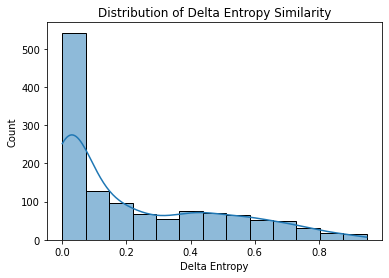

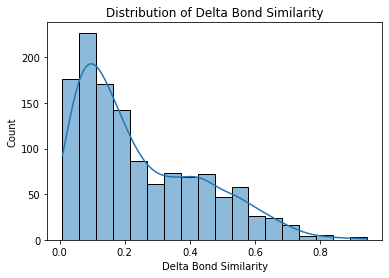

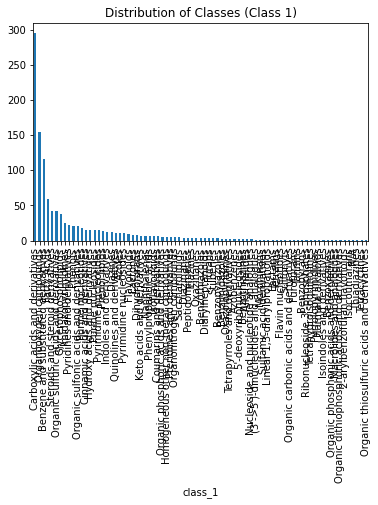

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of delta_entropy
sns.histplot(sample_df['delta_entropy'], kde=True)
plt.title('Distribution of Delta Entropy Similarity')
plt.xlabel('Delta Entropy')
plt.show()

# Distribution of delta_bond_similarity
sns.histplot(sample_df['delta_bond_similarity'], kde=True)
plt.title('Distribution of Delta Bond Similarity')
plt.xlabel('Delta Bond Similarity')
plt.show()

# Class distribution
sample_df['class_1'].value_counts().plot(kind='bar')
plt.title('Distribution of Classes (Class 1)')
plt.show()


Text(0.5, 1.0, 'Delta Entropy vs Delta Bond Similarity')

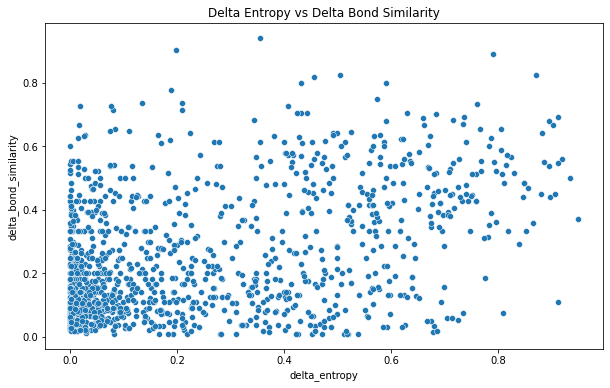

In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Calculate correlations between delta metrics
correlation = stats.pearsonr(sample_df['delta_entropy'], sample_df['delta_bond_similarity'])

# 2. Plot overall relationship
plt.figure(figsize=(10,6))
sns.scatterplot(data=sample_df, x='delta_entropy', y='delta_bond_similarity')
plt.title('Delta Entropy vs Delta Bond Similarity')

In [112]:
from scipy.stats import spearmanr

# Compute correlation for the entire filtered dataframe
corr, p_value = spearmanr(filtered_df['delta_entropy'], filtered_df['delta_bond_similarity'])
print(f"Spearman Correlation: {corr}, P-value: {p_value}")

# Compute Spearman correlation for each class and include the sample size (N)
class_corrs = filtered_df.groupby('class_1').apply(
    lambda x: pd.Series({
        'spearman_corr': spearmanr(x['delta_entropy'], x['delta_bond_similarity'])[0],
        'n': len(x)
    })
).reset_index()

# Sort by Spearman correlation and display the results
print(class_corrs.sort_values(by='spearman_corr', ascending=False))


Spearman Correlation: 0.3765665129917246, P-value: 2.2510168996987947e-34
                                   class_1  spearman_corr      n
20              Quinolines and derivatives       0.818445   11.0
9                  Indoles and derivatives       0.617548   12.0
7            Hydroxy acids and derivatives       0.608895   15.0
15                      Purine nucleosides       0.602374   15.0
19                  Pyrimidine nucleotides       0.581906   15.0
18                  Pyrimidine nucleosides       0.528878   10.0
10  Organic sulfonic acids and derivatives       0.521825   20.0
12                  Organooxygen compounds       0.519273  154.0
16                      Purine nucleotides       0.511716   18.0
17               Pyridines and derivatives       0.465932   22.0
13                                 Phenols       0.427711   20.0
11  Organic sulfuric acids and derivatives       0.410877   42.0
1      Benzene and substituted derivatives       0.390815  116.0
0               

In [110]:
# Set minimum class size
min_class_size = 10

# Filter classes with sufficient compounds
class_counts = sample_df['class_1'].value_counts()
valid_classes = class_counts[class_counts >= min_class_size].index
filtered_df = sample_df[sample_df['class_1'].isin(valid_classes)]

# Check the updated number of classes
print(f"Number of valid classes: {len(valid_classes)}")


Number of valid classes: 22


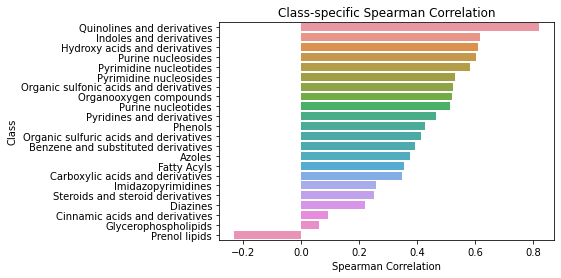

In [107]:
# Group by class_1 and compute correlation for valid classes
class_corrs = filtered_df.groupby('class_1').apply(
    lambda x: spearmanr(x['delta_entropy'], x['delta_bond_similarity'])[0]
).reset_index(name='spearman_corr')

# Sort by correlation for visualization
class_corrs = class_corrs.sort_values(by='spearman_corr', ascending=False)

# Visualize correlations
sns.barplot(x='spearman_corr', y='class_1', data=class_corrs, orient='h')
plt.title('Class-specific Spearman Correlation')
plt.xlabel('Spearman Correlation')
plt.ylabel('Class')
plt.show()


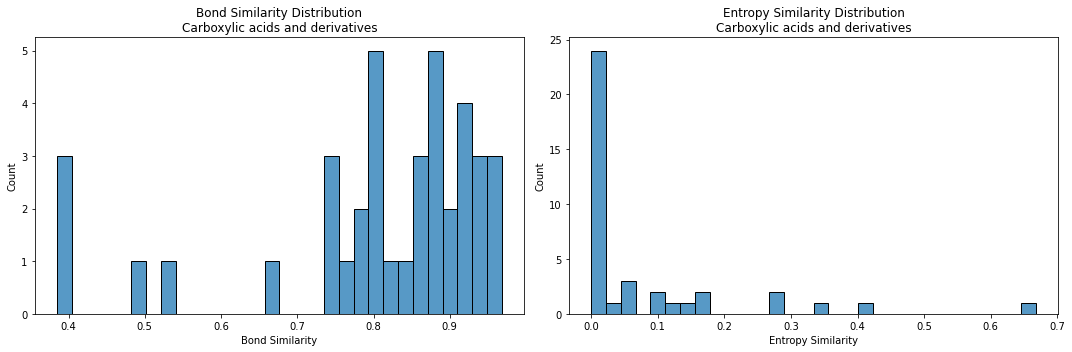


Summary Statistics for Carboxylic acids and derivatives pairs:

Bond Similarity:
count    39.000000
mean      0.198342
std       0.159293
min       0.031579
25%       0.090054
50%       0.142857
75%       0.227833
max       0.615385
Name: delta_bond_similarity, dtype: float64

Entropy Similarity:
count    39.000000
mean      0.079782
std       0.141714
min       0.000000
25%       0.002686
50%       0.011735
75%       0.093370
max       0.668113
Name: delta_entropy, dtype: float64

Number of compound pairs: 39


In [90]:
# Filter for pairs where both compounds are Carboxylic acids and derivatives
carboxylic_pairs = sample_df[
    (sample_df['class_1'] == 'Organooxygen compounds') & 
    (sample_df['class_2'] == 'Organooxygen compounds')
]

# Create subplot with two histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot bond similarity distribution
sns.histplot(data=carboxylic_pairs, x='bond_similarity2', bins=30, ax=ax1)
ax1.set_title('Bond Similarity Distribution\nCarboxylic acids and derivatives')
ax1.set_xlabel('Bond Similarity')
ax1.set_ylabel('Count')

# Plot entropy similarity distribution
sns.histplot(data=carboxylic_pairs, x='delta_entropy', bins=30, ax=ax2)
ax2.set_title('Entropy Similarity Distribution\nCarboxylic acids and derivatives')
ax2.set_xlabel('Entropy Similarity')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

# Print some summary statistics
print("\nSummary Statistics for Carboxylic acids and derivatives pairs:")
print("\nBond Similarity:")
print(carboxylic_pairs['delta_bond_similarity'].describe())
print("\nEntropy Similarity:")
print(carboxylic_pairs['delta_entropy'].describe())

# Count number of pairs
print(f"\nNumber of compound pairs: {len(carboxylic_pairs)}")

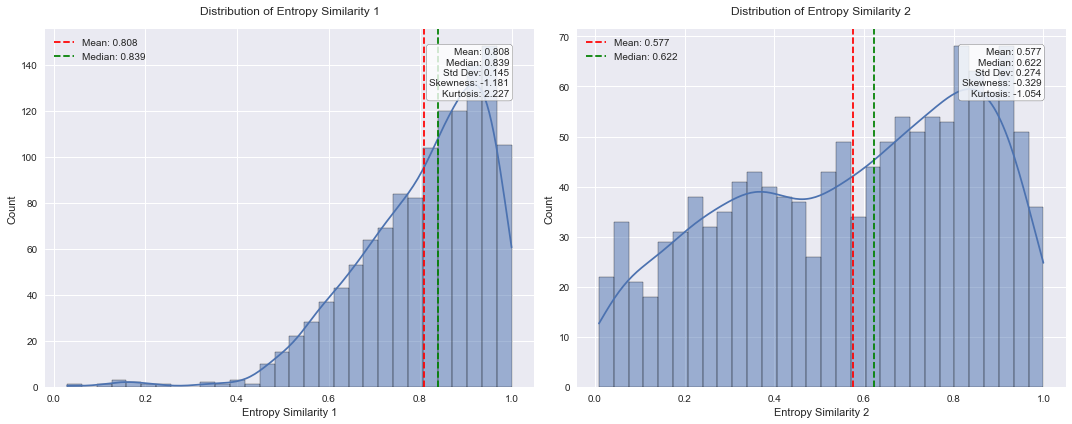


Shapiro-Wilk test for normality:
Entropy Similarity 1: ShapiroResult(statistic=0.9176406264305115, pvalue=1.2427391760918745e-25)
Entropy Similarity 2: ShapiroResult(statistic=0.9493629932403564, pvalue=2.0769899336031315e-20)

Paired t-test:
TtestResult(statistic=32.656974045453566, pvalue=5.854178188423103e-170, df=1259)

Wilcoxon signed-rank test:
WilcoxonResult(statistic=0.0, pvalue=8.55239469010467e-199)

Summary Statistics:

Entropy Similarity 1:
count    1260.000000
mean        0.808080
std         0.144507
min         0.028952
25%         0.719813
50%         0.839453
75%         0.922527
max         1.000000
Name: entropy_similarity1, dtype: float64

Entropy Similarity 2:
count    1260.000000
mean        0.576590
std         0.273768
min         0.009184
25%         0.354029
50%         0.621966
75%         0.815680
max         1.000000
Name: entropy_similarity2, dtype: float64


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot distributions
sns.histplot(data=output_df, x='entropy_similarity1', bins=30, kde=True, ax=ax1)
sns.histplot(data=output_df, x='entropy_similarity2', bins=30, kde=True, ax=ax2)

# Calculate basic statistics for entropy_similarity1
mean1 = output_df['entropy_similarity1'].mean()
median1 = output_df['entropy_similarity1'].median()
std1 = output_df['entropy_similarity1'].std()
skew1 = stats.skew(output_df['entropy_similarity1'])
kurt1 = stats.kurtosis(output_df['entropy_similarity1'])

# Calculate basic statistics for entropy_similarity2
mean2 = output_df['entropy_similarity2'].mean()
median2 = output_df['entropy_similarity2'].median()
std2 = output_df['entropy_similarity2'].std()
skew2 = stats.skew(output_df['entropy_similarity2'])
kurt2 = stats.kurtosis(output_df['entropy_similarity2'])

# Add vertical lines for mean and median
ax1.axvline(mean1, color='red', linestyle='--', label=f'Mean: {mean1:.3f}')
ax1.axvline(median1, color='green', linestyle='--', label=f'Median: {median1:.3f}')
ax2.axvline(mean2, color='red', linestyle='--', label=f'Mean: {mean2:.3f}')
ax2.axvline(median2, color='green', linestyle='--', label=f'Median: {median2:.3f}')

# Add statistical information as text boxes
stats_text1 = (f'Mean: {mean1:.3f}\n'
              f'Median: {median1:.3f}\n'
              f'Std Dev: {std1:.3f}\n'
              f'Skewness: {skew1:.3f}\n'
              f'Kurtosis: {kurt1:.3f}')

stats_text2 = (f'Mean: {mean2:.3f}\n'
              f'Median: {median2:.3f}\n'
              f'Std Dev: {std2:.3f}\n'
              f'Skewness: {skew2:.3f}\n'
              f'Kurtosis: {kurt2:.3f}')

# Add text boxes
ax1.text(0.95, 0.95, stats_text1,
         transform=ax1.transAxes,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax2.text(0.95, 0.95, stats_text2,
         transform=ax2.transAxes,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Customize plots
ax1.set_title('Distribution of Entropy Similarity 1', fontsize=12, pad=15)
ax2.set_title('Distribution of Entropy Similarity 2', fontsize=12, pad=15)
ax1.set_xlabel('Entropy Similarity 1')
ax2.set_xlabel('Entropy Similarity 2')
ax1.legend()
ax2.legend()

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

# Perform statistical tests
print("\nShapiro-Wilk test for normality:")
print("Entropy Similarity 1:", stats.shapiro(output_df['entropy_similarity1']))
print("Entropy Similarity 2:", stats.shapiro(output_df['entropy_similarity2']))

# Perform paired t-test and Wilcoxon signed-rank test
print("\nPaired t-test:")
print(stats.ttest_rel(output_df['entropy_similarity1'], output_df['entropy_similarity2']))
print("\nWilcoxon signed-rank test:")
print(stats.wilcoxon(output_df['entropy_similarity1'], output_df['entropy_similarity2']))

# Print summary statistics
print("\nSummary Statistics:")
print("\nEntropy Similarity 1:")
print(output_df['entropy_similarity1'].describe())
print("\nEntropy Similarity 2:")
print(output_df['entropy_similarity2'].describe())

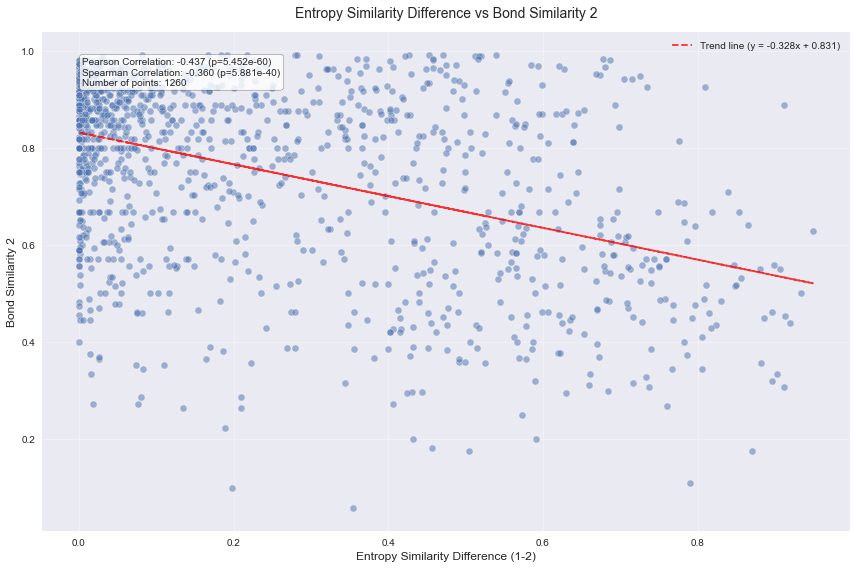


Summary Statistics:

Entropy Similarity Difference:
count    1260.000000
mean        0.231490
std         0.251618
min         0.000000
25%         0.017423
50%         0.115968
75%         0.421856
max         0.949105
Name: entropy_similarity_diff, dtype: float64

Bond Similarity 2:
count    1260.000000
mean        0.755595
std         0.188465
min         0.057143
25%         0.618831
50%         0.818182
75%         0.909091
max         0.991150
Name: bond_similarity2, dtype: float64


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Calculate entropy similarity difference
output_df['entropy_similarity_diff'] = output_df['entropy_similarity1'] - output_df['entropy_similarity2']

# Create figure and axis
plt.figure(figsize=(12, 8))

# Create scatter plot
sns.scatterplot(data=output_df, 
                x='entropy_similarity_diff',
                y='bond_similarity2',
                alpha=0.5)

# Add trend line
z = np.polyfit(output_df['entropy_similarity_diff'], output_df['bond_similarity2'], 1)
p = np.poly1d(z)
plt.plot(output_df['entropy_similarity_diff'], p(output_df['entropy_similarity_diff']), 
         "r--", alpha=0.8, label=f'Trend line (y = {z[0]:.3f}x + {z[1]:.3f})')

# Calculate correlation coefficient
correlation = stats.pearsonr(output_df['entropy_similarity_diff'], output_df['bond_similarity2'])
spearman_corr = stats.spearmanr(output_df['entropy_similarity_diff'], output_df['bond_similarity2'])

# Add statistical information
stats_text = (f'Pearson Correlation: {correlation[0]:.3f} (p={correlation[1]:.3e})\n'
             f'Spearman Correlation: {spearman_corr[0]:.3f} (p={spearman_corr[1]:.3e})\n'
             f'Number of points: {len(output_df)}')

plt.text(0.05, 0.95, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Customize the plot
plt.title('Entropy Similarity Difference vs Bond Similarity 2', fontsize=14, pad=15)
plt.xlabel('Entropy Similarity Difference (1-2)', fontsize=12)
plt.ylabel('Bond Similarity 2', fontsize=12)
plt.legend()

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print("\nEntropy Similarity Difference:")
print(output_df['entropy_similarity_diff'].describe())
print("\nBond Similarity 2:")
print(output_df['bond_similarity2'].describe())

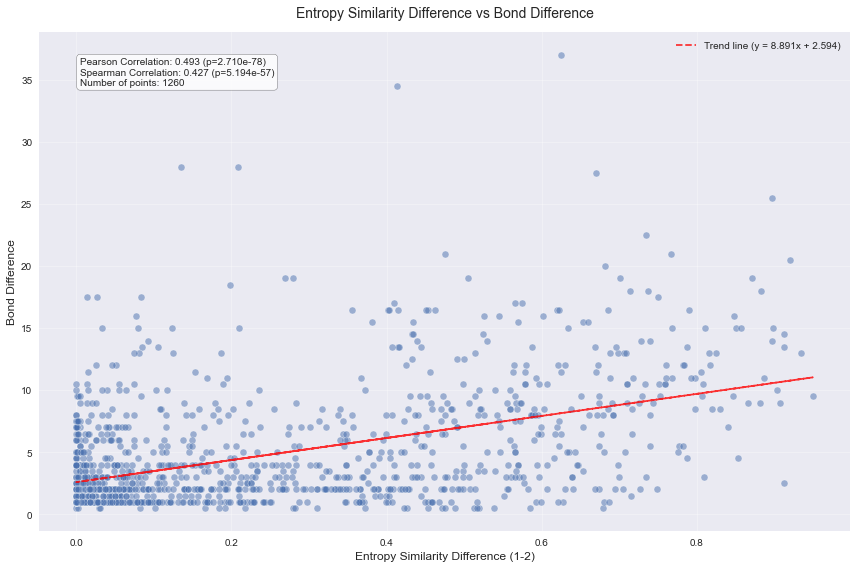


Summary Statistics:

Entropy Similarity Difference:
count    1260.000000
mean        0.231490
std         0.251618
min         0.000000
25%         0.017423
50%         0.115968
75%         0.421856
max         0.949105
Name: entropy_similarity_diff, dtype: float64

Bond Difference:
count    1260.000000
mean        4.651984
std         4.533753
min         0.500000
25%         1.500000
50%         3.000000
75%         6.500000
max        37.000000
Name: bond_difference, dtype: float64

Shapiro-Wilk test for normality:
Entropy Similarity Difference: ShapiroResult(statistic=0.8418634533882141, pvalue=1.2306794943250745e-33)
Bond Difference: ShapiroResult(statistic=0.7769688367843628, pvalue=2.568936575436714e-38)


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Calculate entropy similarity difference
output_df['entropy_similarity_diff'] = output_df['entropy_similarity1'] - output_df['entropy_similarity2']

# Create figure and axis
plt.figure(figsize=(12, 8))

# Create scatter plot
sns.scatterplot(data=output_df, 
                x='entropy_similarity_diff',
                y='bond_difference',
                alpha=0.5)

# Add trend line
z = np.polyfit(output_df['entropy_similarity_diff'], output_df['bond_difference'], 1)
p = np.poly1d(z)
plt.plot(output_df['entropy_similarity_diff'], p(output_df['entropy_similarity_diff']), 
         "r--", alpha=0.8, label=f'Trend line (y = {z[0]:.3f}x + {z[1]:.3f})')

# Calculate correlation coefficients
correlation = stats.pearsonr(output_df['entropy_similarity_diff'], output_df['bond_difference'])
spearman_corr = stats.spearmanr(output_df['entropy_similarity_diff'], output_df['bond_difference'])

# Add statistical information
stats_text = (f'Pearson Correlation: {correlation[0]:.3f} (p={correlation[1]:.3e})\n'
             f'Spearman Correlation: {spearman_corr[0]:.3f} (p={spearman_corr[1]:.3e})\n'
             f'Number of points: {len(output_df)}')

plt.text(0.05, 0.95, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Customize the plot
plt.title('Entropy Similarity Difference vs Bond Difference', fontsize=14, pad=15)
plt.xlabel('Entropy Similarity Difference (1-2)', fontsize=12)
plt.ylabel('Bond Difference', fontsize=12)
plt.legend()

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print("\nEntropy Similarity Difference:")
print(output_df['entropy_similarity_diff'].describe())
print("\nBond Difference:")
print(output_df['bond_difference'].describe())

# Print additional statistical tests
print("\nShapiro-Wilk test for normality:")
print("Entropy Similarity Difference:", stats.shapiro(output_df['entropy_similarity_diff']))
print("Bond Difference:", stats.shapiro(output_df['bond_difference']))

In [23]:
import pandas as pd
import numpy as np
from scipy import stats

# Calculate the difference in entropy similarities
output_df['entropy_similarity_diff'] = output_df['entropy_similarity1'] - output_df['entropy_similarity2']

# Basic statistics
print("Distribution Statistics of Entropy Similarity Differences:")
print("-" * 50)
print(output_df['entropy_similarity_diff'].describe())

# Calculate additional statistical measures
print("\nAdditional Statistics:")
print("-" * 50)
print(f"Skewness: {stats.skew(output_df['entropy_similarity_diff']):.4f}")
print(f"Kurtosis: {stats.kurtosis(output_df['entropy_similarity_diff']):.4f}")

# Count positive and negative differences
pos_diff = (output_df['entropy_similarity_diff'] > 0).sum()
neg_diff = (output_df['entropy_similarity_diff'] < 0).sum()
zero_diff = (output_df['entropy_similarity_diff'] == 0).sum()

print("\nDifference Direction Counts:")
print("-" * 50)
print(f"Positive differences: {pos_diff} (entropy_similarity1 > entropy_similarity2)")
print(f"Negative differences: {neg_diff} (entropy_similarity1 < entropy_similarity2)")
print(f"Zero differences: {zero_diff} (entropy_similarity1 = entropy_similarity2)")

# Show some example cases
print("\nExample cases:")
print("-" * 50)
print("\nLargest positive differences (where first hit has much higher similarity):")
print(output_df.nlargest(3, 'entropy_similarity_diff')[
    ['wiki_id', 'name1', 'name2', 'entropy_similarity1', 'entropy_similarity2', 'entropy_similarity_diff']
])

print("\nLargest negative differences (where second hit has much higher similarity):")
print(output_df.nsmallest(3, 'entropy_similarity_diff')[
    ['wiki_id', 'name1', 'name2', 'entropy_similarity1', 'entropy_similarity2', 'entropy_similarity_diff']
])

Distribution Statistics of Entropy Similarity Differences:
--------------------------------------------------
count    1260.000000
mean        0.231490
std         0.251618
min         0.000000
25%         0.017423
50%         0.115968
75%         0.421856
max         0.949105
Name: entropy_similarity_diff, dtype: float64

Additional Statistics:
--------------------------------------------------
Skewness: 0.9202
Kurtosis: -0.3768

Difference Direction Counts:
--------------------------------------------------
Positive differences: 1206 (entropy_similarity1 > entropy_similarity2)
Negative differences: 0 (entropy_similarity1 < entropy_similarity2)
Zero differences: 54 (entropy_similarity1 = entropy_similarity2)

Example cases:
--------------------------------------------------

Largest positive differences (where first hit has much higher similarity):
           wiki_id                            name1  \
656   aPUDE1U/4682    Propofol .beta.-D-glucuronide   
1200   aPUDE1U/919    Propof

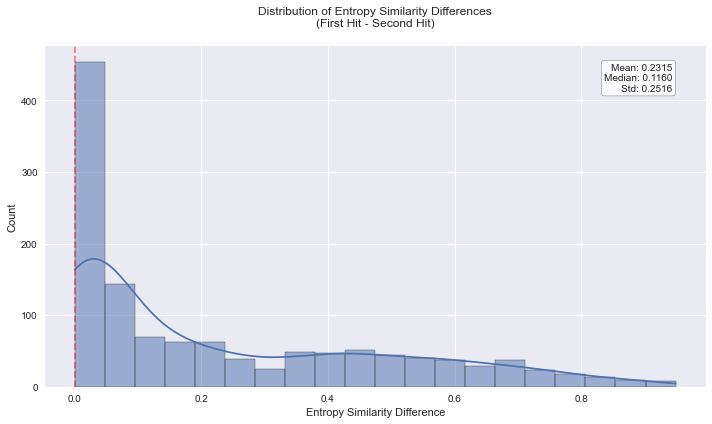

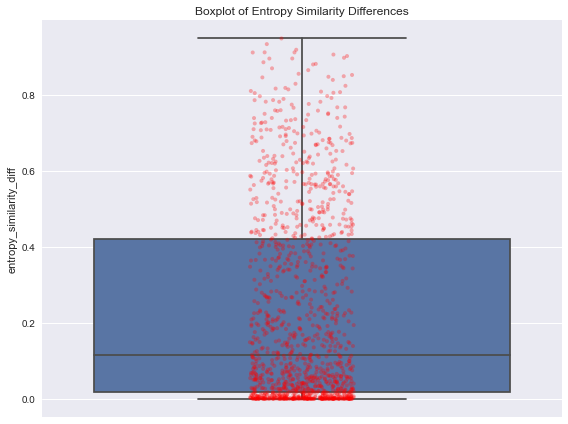


Summary Statistics:
--------------------------------------------------
count    1260.000000
mean        0.231490
std         0.251618
min         0.000000
25%         0.017423
50%         0.115968
75%         0.421856
max         0.949105
Name: entropy_similarity_diff, dtype: float64

Percentage of cases where first hit has higher similarity: 100.0%


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate entropy similarity differences
output_df['entropy_similarity_diff'] = output_df['entropy_similarity1'] - output_df['entropy_similarity2']

# Create figure for histogram
plt.figure(figsize=(10, 6))

# Create histogram with KDE
sns.histplot(data=output_df, x='entropy_similarity_diff', bins=20, kde=True)

# Customize plot
plt.title('Distribution of Entropy Similarity Differences\n(First Hit - Second Hit)', pad=20)
plt.xlabel('Entropy Similarity Difference')
plt.ylabel('Count')

# Add vertical line at x=0
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)

# Add text box with statistics
stats_text = (f'Mean: {output_df["entropy_similarity_diff"].mean():.4f}\n'
              f'Median: {output_df["entropy_similarity_diff"].median():.4f}\n'
              f'Std: {output_df["entropy_similarity_diff"].std():.4f}')
plt.text(0.95, 0.95, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Adjust layout
plt.tight_layout()
plt.show()

# Create figure for boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=output_df['entropy_similarity_diff'])
plt.title('Boxplot of Entropy Similarity Differences')
plt.ylabel('Entropy Similarity Difference')

# Add individual points with jitter
sns.stripplot(y=output_df['entropy_similarity_diff'], color='red', alpha=0.3, size=4)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print("-" * 50)
print(output_df['entropy_similarity_diff'].describe())

# Calculate percentage of cases where first hit has higher similarity
better_first = (output_df['entropy_similarity_diff'] >= 0).mean() * 100
print(f"\nPercentage of cases where first hit has higher similarity: {better_first:.1f}%")

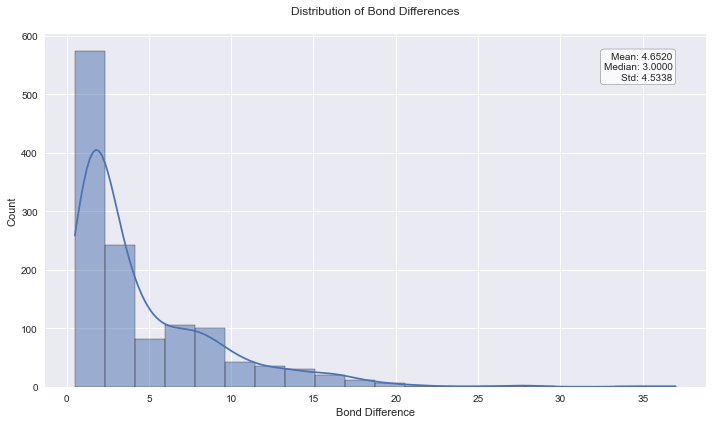

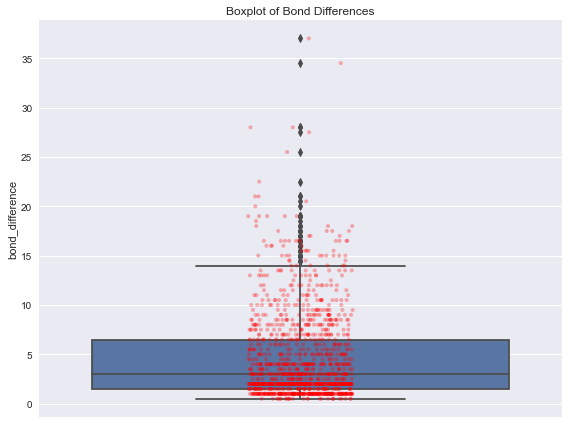


Summary Statistics for Bond Differences:
--------------------------------------------------
count    1260.000000
mean        4.651984
std         4.533753
min         0.500000
25%         1.500000
50%         3.000000
75%         6.500000
max        37.000000
Name: bond_difference, dtype: float64

Additional Statistics:
--------------------------------------------------
Skewness: 2.0375
Kurtosis: 5.9421


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create figure for histogram
plt.figure(figsize=(10, 6))

# Create histogram with KDE
sns.histplot(data=output_df, x='bond_difference', bins=20, kde=True)

# Customize plot
plt.title('Distribution of Bond Differences', pad=20)
plt.xlabel('Bond Difference')
plt.ylabel('Count')

# Add text box with statistics
stats_text = (f'Mean: {output_df["bond_difference"].mean():.4f}\n'
              f'Median: {output_df["bond_difference"].median():.4f}\n'
              f'Std: {output_df["bond_difference"].std():.4f}')
plt.text(0.95, 0.95, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Adjust layout
plt.tight_layout()
plt.show()

# Create figure for boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=output_df['bond_difference'])
plt.title('Boxplot of Bond Differences')
plt.ylabel('Bond Difference')

# Add individual points with jitter
sns.stripplot(y=output_df['bond_difference'], color='red', alpha=0.3, size=4)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics for Bond Differences:")
print("-" * 50)
print(output_df['bond_difference'].describe())

# Calculate some additional statistics
print("\nAdditional Statistics:")
print("-" * 50)
print(f"Skewness: {output_df['bond_difference'].skew():.4f}")
print(f"Kurtosis: {output_df['bond_difference'].kurtosis():.4f}")

In [44]:
# Read both files
all_references = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/data/all_references.csv')
predicted = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/data/predicted_result.csv')

# Merge predicted RT for smiles1
output_df = pd.merge(
    output_df,
    predicted[['smiles', 'predicted_rt']],
    left_on='smiles1',
    right_on='smiles',
    how='left'
).rename(columns={'predicted_rt': 'predicted_rt1'})

# Merge predicted RT for smiles2
output_df = pd.merge(
    output_df,
    predicted[['smiles', 'predicted_rt']],
    left_on='smiles2',
    right_on='smiles',
    how='left'
).rename(columns={'predicted_rt': 'predicted_rt2'})

# Calculate delta RT (maintaining directionality: rt1 - rt2)
output_df['delta_predicted_rt'] = output_df['predicted_rt1'] - output_df['predicted_rt2']

# Remove extra smiles columns from merges
output_df = output_df.drop(['smiles_x', 'smiles_y'], axis=1, errors='ignore')

print("Shape of final dataframe:", output_df.shape)
print("\nFirst few rows of delta values:")
print(output_df[['smiles1', 'predicted_rt1', 'smiles2', 'predicted_rt2', 'delta_predicted_rt']].head())

ValueError: Columns must be same length as key

In [45]:
# Check the columns we have
print("Columns in output_df:", output_df.columns.tolist())

# Check if we have the predicted RT columns
print("\nDo we have predicted_rt1?", 'predicted_rt1' in output_df.columns)
print("Do we have predicted_rt2?", 'predicted_rt2' in output_df.columns)

# Look at the first few rows to see what we're working with
print("\nFirst few rows of the relevant columns:")
print(output_df[['smiles1', 'smiles2']].head())

print("\nShape of predicted dataframe:", predicted.shape)
print("First few rows of predicted df:")
print(predicted.head())

# Try the merge step by step
# First merge
output_df1 = pd.merge(
    output_df,
    predicted[['smiles', 'predicted_rt']],
    left_on='smiles1',
    right_on='smiles',
    how='left'
)
print("\nAfter first merge - shape:", output_df1.shape)

# Second merge
output_df2 = pd.merge(
    output_df1,
    predicted[['smiles', 'predicted_rt']],
    left_on='smiles2',
    right_on='smiles',
    how='left'
)
print("After second merge - shape:", output_df2.shape)

Columns in output_df: ['wiki_id', 'reference_index', 'comparison_index', 'id1', 'name1', 'smiles1', 'db1', 'adduct1', 'precursor_mz1', 'entropy_similarity1', 'bond_similarity1', 'id2', 'name2', 'smiles2', 'db2', 'adduct2', 'precursor_mz2', 'entropy_similarity2', 'bond_similarity2', 'common_bond_number', 'mol1_bond_number', 'mol2_bond_number', 'bond_difference', 'minimal_diff', 'delta_bond_similarity', 'entropy_similarity_diff', 'predicted_rt1', 'predicted_rt2', 'delta_predicted_rt', 'smiles_x', 'predicted_rt1', 'smiles_y', 'predicted_rt2']

Do we have predicted_rt1? True
Do we have predicted_rt2? True

First few rows of the relevant columns:
                                             smiles1  \
0  COc1ccc(-c2coc3cc(OC4OC(COC5OCC(O)(COC6OCC(O)(...   
1  C(C1C(C(C(C(O1)OC2C(OC(C(C2O)O)OC3C(OC(C(C3O)O...   
2                   O=C(O)C1OC(Oc2ccccc2)C(O)C(O)C1O   
3                NC(CCC(=O)NC(CCC(=O)O)C(=O)O)C(=O)O   
4  CCCCCC=CCC=CCCCCCCCC(=O)OC(COC(=O)CCCCCCCCCCCC...   

             

MergeError: Passing 'suffixes' which cause duplicate columns {'smiles_x'} is not allowed.

In [46]:
# Check current values
print("Sample of current values:")
print(output_df[['predicted_rt1', 'predicted_rt2', 'delta_predicted_rt']].head())

# Calculate new delta_rt directly
output_df['new_delta_rt'] = output_df['predicted_rt1'].subtract(output_df['predicted_rt2'])

# Compare new vs old delta
print("\nComparing new vs old delta RT:")
print(output_df[['predicted_rt1', 'predicted_rt2', 'delta_predicted_rt', 'new_delta_rt']].head())

# Check for any discrepancies
discrepancies = output_df[abs(output_df['delta_predicted_rt'] - output_df['new_delta_rt']) > 0.001]
print("\nNumber of discrepancies:", len(discrepancies))

if len(discrepancies) > 0:
    print("\nSample of discrepancies:")
    print(discrepancies[['predicted_rt1', 'predicted_rt2', 'delta_predicted_rt', 'new_delta_rt']].head())

Sample of current values:
   predicted_rt1  predicted_rt1  predicted_rt2  predicted_rt2  \
0     110.362183     110.362183      35.040039      35.040039   
1     142.065826     142.065826     142.493774     142.493774   
2      93.936150      93.936150      30.218231      30.218231   
3     140.962921     140.962921     134.608429     134.608429   
4      49.393967      49.393967      52.145409      52.145409   

   delta_predicted_rt  
0           75.322144  
1            0.427948  
2           63.717918  
3            6.354492  
4            2.751442  


ValueError: Cannot set a DataFrame with multiple columns to the single column new_delta_rt

In [47]:
# First, let's remove duplicate columns
output_df = output_df.loc[:, ~output_df.columns.duplicated()]

# Now calculate delta_rt
output_df['delta_predicted_rt'] = output_df['predicted_rt1'] - output_df['predicted_rt2']

# Check the results
print("After removing duplicates and calculating delta RT:")
print(output_df[['predicted_rt1', 'predicted_rt2', 'delta_predicted_rt']].head())

# Optional: verify all columns are unique
print("\nAll columns:", output_df.columns.tolist())

After removing duplicates and calculating delta RT:
   predicted_rt1  predicted_rt2  delta_predicted_rt
0     110.362183      35.040039           75.322144
1     142.065826     142.493774           -0.427948
2      93.936150      30.218231           63.717918
3     140.962921     134.608429            6.354492
4      49.393967      52.145409           -2.751442

All columns: ['wiki_id', 'reference_index', 'comparison_index', 'id1', 'name1', 'smiles1', 'db1', 'adduct1', 'precursor_mz1', 'entropy_similarity1', 'bond_similarity1', 'id2', 'name2', 'smiles2', 'db2', 'adduct2', 'precursor_mz2', 'entropy_similarity2', 'bond_similarity2', 'common_bond_number', 'mol1_bond_number', 'mol2_bond_number', 'bond_difference', 'minimal_diff', 'delta_bond_similarity', 'entropy_similarity_diff', 'predicted_rt1', 'predicted_rt2', 'delta_predicted_rt', 'smiles_x', 'smiles_y']


<ipython-input-47-4732ff4abdba>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  output_df['delta_predicted_rt'] = output_df['predicted_rt1'] - output_df['predicted_rt2']


In [48]:
# Create a clean copy of the dataframe
output_df = output_df.loc[:, ~output_df.columns.duplicated()].copy()

# Remove unnecessary columns (smiles_x and smiles_y from previous merges)
output_df = output_df.drop(['smiles_x', 'smiles_y'], axis=1)

# Calculate delta_rt using proper indexing
output_df.loc[:, 'delta_predicted_rt'] = output_df['predicted_rt1'] - output_df['predicted_rt2']

# Check the results
print("Clean results with delta RT:")
print(output_df[['predicted_rt1', 'predicted_rt2', 'delta_predicted_rt']].head())

# Show final column list
print("\nFinal columns:")
print(output_df.columns.tolist())

# Optional: save the clean dataframe
# output_df.to_csv('path/to/save/clean_output.csv', index=False)

Clean results with delta RT:
   predicted_rt1  predicted_rt2  delta_predicted_rt
0     110.362183      35.040039           75.322144
1     142.065826     142.493774           -0.427948
2      93.936150      30.218231           63.717918
3     140.962921     134.608429            6.354492
4      49.393967      52.145409           -2.751442

Final columns:
['wiki_id', 'reference_index', 'comparison_index', 'id1', 'name1', 'smiles1', 'db1', 'adduct1', 'precursor_mz1', 'entropy_similarity1', 'bond_similarity1', 'id2', 'name2', 'smiles2', 'db2', 'adduct2', 'precursor_mz2', 'entropy_similarity2', 'bond_similarity2', 'common_bond_number', 'mol1_bond_number', 'mol2_bond_number', 'bond_difference', 'minimal_diff', 'delta_bond_similarity', 'entropy_similarity_diff', 'predicted_rt1', 'predicted_rt2', 'delta_predicted_rt']


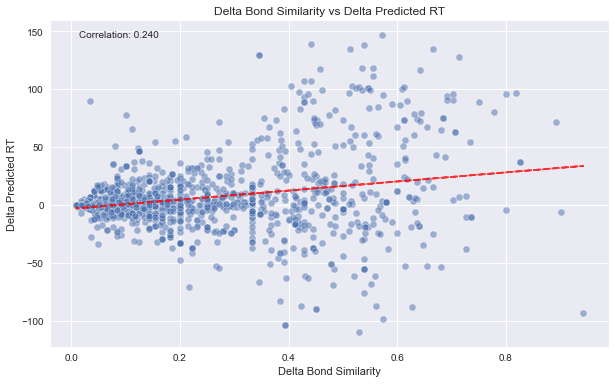


Summary Statistics:

Delta Bond Similarity:
count    1260.000000
mean        0.244405
std         0.188465
min         0.008850
25%         0.090909
50%         0.181818
75%         0.381169
max         0.942857
Name: delta_bond_similarity, dtype: float64

Delta Predicted RT:
count    1260.000000
mean        6.377015
std        30.794033
min      -109.709332
25%        -5.143246
50%         0.978099
75%        12.718245
max       146.586441
Name: delta_predicted_rt, dtype: float64


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=output_df, 
                x='delta_bond_similarity', 
                y='delta_predicted_rt',
                alpha=0.5)

# Add trend line
z = np.polyfit(output_df['delta_bond_similarity'], output_df['delta_predicted_rt'], 1)
p = np.poly1d(z)
plt.plot(output_df['delta_bond_similarity'], p(output_df['delta_bond_similarity']), "r--", alpha=0.8)

# Calculate correlation
correlation = output_df['delta_bond_similarity'].corr(output_df['delta_predicted_rt'])

# Add labels and title
plt.xlabel('Delta Bond Similarity')
plt.ylabel('Delta Predicted RT')
plt.title('Delta Bond Similarity vs Delta Predicted RT')
plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
         transform=plt.gca().transAxes)

plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print("\nDelta Bond Similarity:")
print(output_df['delta_bond_similarity'].describe())
print("\nDelta Predicted RT:")
print(output_df['delta_predicted_rt'].describe())

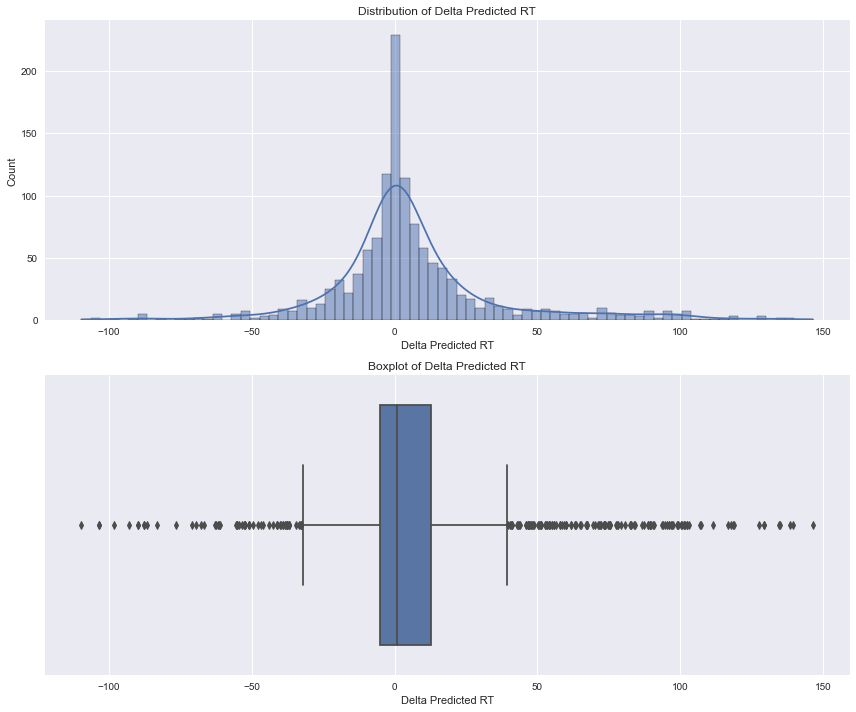


Summary Statistics for Delta Predicted RT:
count    1260.000000
mean        6.377015
std        30.794033
min      -109.709332
25%        -5.143246
50%         0.978099
75%        12.718245
max       146.586441
Name: delta_predicted_rt, dtype: float64

Additional Metrics:
Skewness: 1.089
Kurtosis: 4.041


In [50]:
# Create figure with multiple distribution views
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Histogram with KDE
sns.histplot(data=output_df, 
            x='delta_predicted_rt', 
            kde=True, 
            ax=ax1)
ax1.set_title('Distribution of Delta Predicted RT')
ax1.set_xlabel('Delta Predicted RT')
ax1.set_ylabel('Count')

# Box plot for another view of the distribution
sns.boxplot(data=output_df, 
           x='delta_predicted_rt',
           ax=ax2)
ax2.set_title('Boxplot of Delta Predicted RT')
ax2.set_xlabel('Delta Predicted RT')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics for Delta Predicted RT:")
print(output_df['delta_predicted_rt'].describe())

# Calculate additional metrics
print("\nAdditional Metrics:")
print(f"Skewness: {output_df['delta_predicted_rt'].skew():.3f}")
print(f"Kurtosis: {output_df['delta_predicted_rt'].kurtosis():.3f}")